In [39]:
from Configurations.imports import *

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

In [41]:
# dataset creation 
X = np.array([[10], [20], [30], [40], [50], [60]])
y = np.array([0, 0, 0, 1, 1, 1])

In [42]:
# split the dataset into the train and test split

In [43]:
y_probs = model.predict_proba(X)[:,1]
y_probs.round(2)

y_pred = (y_probs >= 0.5).astype(int)
y_pred


array([0, 0, 0, 1, 1, 1])

In [44]:
def give_pred(threshold):
    y_pred = (y_probs >= threshold).astype(int)

    tp = fp = tn = fn = 0

    for actual, pred in zip(y, y_pred):
        if actual == 1 and pred == 1:
            tp += 1
        elif actual == 0 and pred == 1:
            fp += 1
        elif actual == 0 and pred == 0:
            tn += 1
        elif actual == 1 and pred == 0:
            fn += 1

    TPR = tp / (tp + fn)
    FPR = fp / (fp + tn)

    return TPR, FPR

In [45]:
give_pred(0.1)

(1.0, 0.0)

In [46]:
give_pred(0.05)

(1.0, 0.3333333333333333)

In [59]:
# Creation of the dataset
from sklearn.datasets import make_classification
X,y = make_classification(n_features=5, n_samples=1000, n_classes=2, random_state=43)

# split the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=43, test_size=0.33)

# train the model
model = LogisticRegression()
model.fit(x_train, y_train)

# y_pred = model.predict(x_train)
# dont use this this will prediction not the probability 
y_pred = model.predict_proba(x_train)[:,1] # because we are solving for the class 1 

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, y_pred)

from sklearn.metrics import roc_auc_score
score = roc_auc_score(y_train, y_pred)

score


0.9843516076138875

In [63]:
fpr

array([0.        , 0.        , 0.        , 0.00295858, 0.00295858,
       0.00591716, 0.00591716, 0.00887574, 0.00887574, 0.01183432,
       0.01183432, 0.0147929 , 0.0147929 , 0.01775148, 0.01775148,
       0.02071006, 0.02071006, 0.02662722, 0.02662722, 0.0295858 ,
       0.0295858 , 0.03254438, 0.03254438, 0.03550296, 0.03550296,
       0.03846154, 0.03846154, 0.0443787 , 0.0443787 , 0.05621302,
       0.05621302, 0.0591716 , 0.0591716 , 0.06213018, 0.06213018,
       0.06508876, 0.06508876, 0.07100592, 0.07100592, 0.0739645 ,
       0.0739645 , 0.08579882, 0.08579882, 0.09171598, 0.09171598,
       0.09467456, 0.09467456, 0.10059172, 0.10059172, 0.11538462,
       0.11538462, 0.12130178, 0.12130178, 0.12721893, 0.12721893,
       0.15680473, 0.15680473, 0.15976331, 0.15976331, 0.18639053,
       0.18639053, 0.34615385, 0.34615385, 1.        ])

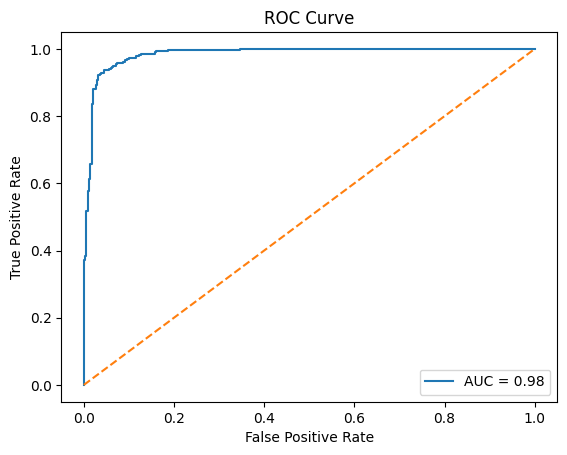

In [ ]:
plt.plot(fpr, tpr, label=f"AUC = {score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [67]:
import numpy as np

j_scores = tpr - fpr
best_index = np.argmax(j_scores)

best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)

Best threshold: 0.5842288758107819
